In [1]:
!pwd

/home/ylnner/Documents/omnet++/omnetpp-6.3.0/projects/florasat_v4_ult_routing/simulations/Test_Individual/results


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import matplotlib.image as mpimg
from scipy.spatial.distance import cdist
import os
import re

number_of_runs = 10

# Read Metrics for Transformer ML Model

In [3]:
def extract_myraan(text):
    #row = group[group['attrname'] == 'iterationvars']['attrvalue'].iloc[0]
    return int(re.search(r'myraan=(\d+)', text).group(1))

In [4]:
# Load the CSV files 

folder = "results_florasat_ml_trf"
total_raans = [165, 175, 185, 195, 205]

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
transformer_vector_dfs = {}
transformer_scalar_dfs = {}

for th in thresholds:
    transformer_vector_dfs[th] = []
    transformer_scalar_dfs[th] = []
    for raan in total_raans:
        raan_folder = 'raan_' + str(raan)
        transformer_vector_dfs[th] = transformer_vector_dfs[th] + [pd.read_csv(os.path.join(folder,raan_folder, f"wML_Transformer_raan_{raan}_threshold_{th}_{seed}_vector.csv")) for seed in range(number_of_runs)]
        transformer_scalar_dfs[th] = transformer_scalar_dfs[th] + [pd.read_csv(os.path.join(folder,raan_folder, f"wML_Transformer_raan_{raan}_threshold_{th}_{seed}_scalar.csv")) for seed in range(number_of_runs)]
        #transformer_vector_dfs[th] = transformer_vector_dfs[th] + [(os.path.join(folder,raan_folder, f"wML_Transformer_raan_{raan}_threshold_{th}_{seed}_vector.csv")) for seed in range(number_of_runs)]
        #transformer_scalar_dfs[th] = transformer_scalar_dfs[th] + [(os.path.join(folder,raan_folder, f"wML_Transformer_raan_{raan}_threshold_{th}_{seed}_scalar.csv")) for seed in range(number_of_runs)]
        

In [5]:
transformer_run_stats_msg_trx_at_dev = {}

for th, config_dfs in transformer_scalar_dfs.items():

    #mean_values = []
    max_values = []
    min_values = []
    count_values = []
    #all_values = []
    for dataR in config_dfs:
        transmitted_msg_df = dataR[dataR['name'].str.contains('transmittedMessages', na=False)]

        values = []
        for val in transmitted_msg_df['value']:
            values.extend(float(v) for v in str(val).strip('"').split())
        
        max_values.append(np.max(values) if values else 0)
        min_values.append(np.min(values) if values else 0)
        count_values.append(sum(values))        

    transformer_run_stats_msg_trx_at_dev[th] = {
        #'meanTrxAtDev': np.mean(all_values),
        'avgMaxMsgTrxAtDev': np.mean(max_values),
        'avgMinMsgTrxAtDev': np.mean(min_values),
        'avgCountMsgTrxAtDev': np.mean(count_values)
    }

In [6]:
transformer_dict_total_data_by_threshold = {}

# Number of repetitions required for successful reception at satellite
transformer_run_stats_rep_num_at_sat = {}
for th, config_dfs in transformer_vector_dfs.items():
    transformer_dict_total_data_by_threshold[th] = {}
    
    max_values = []
    min_values = []

    # Count of repetitions required for successful reception at satellite counted by the ML model and by the KiWan MAC protocol.
    count_reps_model = [] 
    count_reps_mac   = []

    # Total unique packets received at satellite counted by the ML model and by the KiWan MAC protocol.
    total_pkt_values_model  = []
    total_pkt_values_mac    = []

    for dataR in config_dfs:    
        vector_model_df = dataR[dataR['name'].str.contains('Successful Repetition Number counted for the Model', na=False)]
        myraan = extract_myraan(dataR[dataR['attrvalue'].str.contains('myraan', na=False)].iloc[0]['attrvalue'])
        #print('myraan: ', myraan)

        if myraan not in transformer_dict_total_data_by_threshold[th]:
            transformer_dict_total_data_by_threshold[th][myraan] = {}
            transformer_dict_total_data_by_threshold[th][myraan]['Repetitions'] = []
            transformer_dict_total_data_by_threshold[th][myraan]['Packets'] = []

        all_values_model = []

        for vec in vector_model_df['vecvalue']:
            all_values_model.extend(int(val) for val in str(vec).strip('"').split())

        max_values.append(np.max(all_values_model) if all_values_model else 0)
        min_values.append(np.min(all_values_model) if all_values_model else 0)        

        count_reps_model.append(sum(all_values_model)) # sum of all repetitions required to recevive in the satellite.
        total_pkt_values_model.append(len(all_values_model)) # total number of packets.
        
        transformer_dict_total_data_by_threshold[th][myraan]['Repetitions'].append(sum(all_values_model))
        transformer_dict_total_data_by_threshold[th][myraan]['Packets'].append(len(all_values_model))


        vector_mac_df = dataR[dataR['name'].str.contains('Successful Repetition Number counted for MAC protocol', na=False)]
        all_values_mac = []
        for vec in vector_mac_df['vecvalue']:
            all_values_mac.extend(int(val) for val in str(vec).strip('"').split())
        
        count_reps_mac.append(sum(all_values_mac)) # sum of all repetitions required to recevive in the satellite for the KiWan
        total_pkt_values_mac.append(len(all_values_mac)) # total number of packets for the KiWan

    #print('Current count_reps_model: ', len(count_reps_model), np.mean(count_reps_model), count_reps_model)
    #print('Current count_reps_mac: ', len(count_reps_mac), np.mean(total_pkt_values_model), count_reps_mac)
    transformer_run_stats_rep_num_at_sat[th] = {
        'avgMaxRepAtSat': np.mean(max_values),
        'avgMinRepAtSat': np.mean(min_values),
        'avgCountRepAtSatMac': np.mean(count_reps_mac),
        'avgTotalPktAtSatMac': np.mean(total_pkt_values_mac),
        'avgCountRepAtSatModel': np.mean(count_reps_model),
        'avgTotalPktAtSatModel': np.mean(total_pkt_values_model)
    }

In [65]:
import numpy as np
import pandas as pd


def calcular_promedios_y_desviaciones_by_raan_and_th(dict_total_data_transformer, th_transformer, dict_total_data_bilstm, th_bilstm):

    #all_reps = []
    #all_pkts = []

    data_th_transformer = dict_total_data_transformer[th_transformer]

    aux_rows_transformer = []    
    for raan, metrics_by_raan in sorted(data_th_transformer.items()):
        reps = metrics_by_raan['Repetitions']
        pkts = metrics_by_raan['Packets']
                            
        aux_rows_transformer.append({
            'Threshold': th_transformer,
            'RAAN' : raan,
            'Rep_Mean': np.mean(reps),
            'Rep_Std': np.std(reps),
            'Pkt_Mean': np.mean(pkts),
            'Pkt_Std': np.std(pkts)
        })
    
    data_th_bilstm = dict_total_data_bilstm[th_bilstm]
    aux_rows_bilstm = []
    for raan, metrics_by_raan in sorted(data_th_bilstm.items()):
        reps = metrics_by_raan['Repetitions']
        pkts = metrics_by_raan['Packets']
                            
        aux_rows_bilstm.append({
            'Threshold': th_bilstm,
            'RAAN' : raan,
            'Rep_Mean': np.mean(reps),
            'Rep_Std': np.std(reps),
            'Pkt_Mean': np.mean(pkts),
            'Pkt_Std': np.std(pkts)
        })    


    print("=== BILSTM ===")
    print("=== TH:    ===", th_bilstm)
    for idx, item in enumerate(aux_rows_bilstm):
        th = item['Threshold']
        raan = item['RAAN']
        item_bilstm = aux_rows_bilstm[idx]

        print('RAAN: ', raan, '|Pkt Rcv Mean Bi-LSTM: ', round(item_bilstm['Pkt_Mean'], 1), '|Pkt Rcv BiLSTM Std: ', round(item_bilstm['Pkt_Std'], 2)
              , '|Rep Rcv Mean Bi-LSTM: ', round(item_bilstm['Rep_Mean'], 1), '|Rep Rcv BiLSTM Std: ', round(item_bilstm['Rep_Std'], 2))
              
    
    print("=== Transformer ===")
    print("=== TH:    ===", th_transformer)
    for idx, item in enumerate(aux_rows_transformer):
        th = item['Threshold']      
        raan = item['RAAN']  
        item_transformer = aux_rows_transformer[idx]

        print('RAAN', raan, '|Pkt Rcv Mean Transformer: ', round(item_transformer['Pkt_Mean'], 1), '|Pkt Rcv Transformer Std: ', round(item_transformer['Pkt_Std'], 2)
              , '|Rep Rcv Mean Transformer: ', round(item_transformer['Rep_Mean'], 1), '|Rep Rcv Transformer Std: ', round(item_transformer['Rep_Std'], 2))

calcular_promedios_y_desviaciones_by_raan_and_th(transformer_dict_total_data_by_threshold, 0.3, bilstm_dict_total_data_by_threshold, 0.6)

=== BILSTM ===
=== TH:    === 0.6
RAAN:  165 |Pkt Rcv Mean Bi-LSTM:  86.8 |Pkt Rcv BiLSTM Std:  9.23 |Rep Rcv Mean Bi-LSTM:  296.4 |Rep Rcv BiLSTM Std:  31.14
RAAN:  175 |Pkt Rcv Mean Bi-LSTM:  87.0 |Pkt Rcv BiLSTM Std:  10.59 |Rep Rcv Mean Bi-LSTM:  294.3 |Rep Rcv BiLSTM Std:  36.35
RAAN:  185 |Pkt Rcv Mean Bi-LSTM:  91.5 |Pkt Rcv BiLSTM Std:  7.74 |Rep Rcv Mean Bi-LSTM:  307.4 |Rep Rcv BiLSTM Std:  27.26
RAAN:  195 |Pkt Rcv Mean Bi-LSTM:  87.0 |Pkt Rcv BiLSTM Std:  5.85 |Rep Rcv Mean Bi-LSTM:  285.2 |Rep Rcv BiLSTM Std:  27.14
RAAN:  205 |Pkt Rcv Mean Bi-LSTM:  76.0 |Pkt Rcv BiLSTM Std:  6.56 |Rep Rcv Mean Bi-LSTM:  235.2 |Rep Rcv BiLSTM Std:  24.82
=== Transformer ===
=== TH:    === 0.3
RAAN 165 |Pkt Rcv Mean Transformer:  87.6 |Pkt Rcv Transformer Std:  7.35 |Rep Rcv Mean Transformer:  275.9 |Rep Rcv Transformer Std:  25.35
RAAN 175 |Pkt Rcv Mean Transformer:  90.5 |Pkt Rcv Transformer Std:  10.98 |Rep Rcv Mean Transformer:  297.6 |Rep Rcv Transformer Std:  38.3
RAAN 185 |Pkt Rcv M

In [76]:
import numpy as np
import pandas as pd


def calcular_promedios_y_desviaciones(dict_total_data_transformer, dict_total_data_bilstm):

    #all_reps = []
    #all_pkts = []

    
    aux_rows_transformer = []
    for threshold, raans in sorted(dict_total_data_transformer.items()):
        all_reps_transformer = []
        all_pkts_transformer = []
        for raan, metrics in sorted(raans.items()):
            reps = metrics['Repetitions']
            pkts = metrics['Packets']
                        
            all_reps_transformer.extend(reps)
            all_pkts_transformer.extend(pkts)
                    
        aux_rows_transformer.append({
            'Threshold': threshold,            
            'Rep_Mean': np.mean(all_reps_transformer),
            'Rep_Std': np.std(all_reps_transformer),
            'Pkt_Mean': np.mean(all_pkts_transformer),
            'Pkt_Std': np.std(all_pkts_transformer)
        })

    aux_rows_bilstm = []
    for threshold, raans in sorted(dict_total_data_bilstm.items()):
        all_reps_bilstm = []
        all_pkts_bilstm = []
        for raan, metrics in sorted(raans.items()):
            reps = metrics['Repetitions']
            pkts = metrics['Packets']
                        
            all_reps_bilstm.extend(reps)
            all_pkts_bilstm.extend(pkts)
                    
        aux_rows_bilstm.append({
            'Threshold': threshold,            
            'Rep_Mean': np.mean(all_reps_bilstm),
            'Rep_Std': np.std(all_reps_bilstm),
            'Pkt_Mean': np.mean(all_pkts_bilstm),
            'Pkt_Std': np.std(all_pkts_bilstm)
        })


    print("=== BILSTM ===")
    for idx, item in enumerate(aux_rows_bilstm):
        th = item['Threshold']
        item_bilstm = aux_rows_bilstm[idx]

        print('Th: ', th, '|Pkt Rcv Mean Bi-LSTM: ', round(item_bilstm['Pkt_Mean'], 1), '|Pkt Rcv BiLSTM Std: ', round(item_bilstm['Pkt_Std']/item_bilstm['Pkt_Mean'], 2)
              , '|Rep Rcv Mean Bi-LSTM: ', round(item_bilstm['Rep_Mean'], 1), '|Rep Rcv BiLSTM Std: ', round(item_bilstm['Rep_Std'], 2))
              
    
    print("=== Transformer ===")
    for idx, item in enumerate(aux_rows_transformer):
        th = item['Threshold']        
        item_transformer = aux_rows_transformer[idx]

        print('Th: ', th, '|Pkt Rcv Mean Transformer: ', round(item_transformer['Pkt_Mean'], 1), '|Pkt Rcv Transformer Std: ', round(item_transformer['Pkt_Std'], 2)
              , '|Rep Rcv Mean Transformer: ', round(item_transformer['Rep_Mean'], 1), '|Rep Rcv Transformer Std: ', round(item_transformer['Rep_Std'], 2))

# --- EJEMPLO DE USO ---
# resultados = calcular_promedios_y_desviaciones(dict_total_data_by_threshold)

In [77]:
calcular_promedios_y_desviaciones(transformer_dict_total_data_by_threshold, bilstm_dict_total_data_by_threshold)

=== BILSTM ===
Th:  0.1 |Pkt Rcv Mean Bi-LSTM:  80.0 |Pkt Rcv BiLSTM Std:  0.13 |Rep Rcv Mean Bi-LSTM:  282.9 |Rep Rcv BiLSTM Std:  39.46
Th:  0.2 |Pkt Rcv Mean Bi-LSTM:  80.3 |Pkt Rcv BiLSTM Std:  0.13 |Rep Rcv Mean Bi-LSTM:  283.8 |Rep Rcv BiLSTM Std:  39.4
Th:  0.3 |Pkt Rcv Mean Bi-LSTM:  82.2 |Pkt Rcv BiLSTM Std:  0.12 |Rep Rcv Mean Bi-LSTM:  289.9 |Rep Rcv BiLSTM Std:  39.01
Th:  0.4 |Pkt Rcv Mean Bi-LSTM:  85.0 |Pkt Rcv BiLSTM Std:  0.12 |Rep Rcv Mean Bi-LSTM:  299.2 |Rep Rcv BiLSTM Std:  40.53
Th:  0.5 |Pkt Rcv Mean Bi-LSTM:  86.9 |Pkt Rcv BiLSTM Std:  0.11 |Rep Rcv Mean Bi-LSTM:  299.8 |Rep Rcv BiLSTM Std:  37.46
Th:  0.6 |Pkt Rcv Mean Bi-LSTM:  85.7 |Pkt Rcv BiLSTM Std:  0.11 |Rep Rcv Mean Bi-LSTM:  283.7 |Rep Rcv BiLSTM Std:  38.93
Th:  0.7 |Pkt Rcv Mean Bi-LSTM:  81.0 |Pkt Rcv BiLSTM Std:  0.12 |Rep Rcv Mean Bi-LSTM:  252.5 |Rep Rcv BiLSTM Std:  42.3
Th:  0.8 |Pkt Rcv Mean Bi-LSTM:  71.6 |Pkt Rcv BiLSTM Std:  0.14 |Rep Rcv Mean Bi-LSTM:  200.4 |Rep Rcv BiLSTM Std:  39.38
Th:

In [42]:
calcular_promedios_y_desviaciones(bilstm_dict_total_data_by_threshold)

          ESTADÍSTICAS GLOBALES DEL DATASET        
Total de experimentos/muestras analizadas: 500
REPETICIONES -> Promedio (Mean): 235.49 | Desv. Est. (Std): 90.49
PAQUETES     -> Promedio (Mean): 72.42 | Desv. Est. (Std): 21.55

=== DESGLOSE DETALLADO POR THRESHOLD Y RAAN ===
Threshold Rep_Mean Rep_Std Pkt_Mean Pkt_Std
     0.10   252.30   42.15    70.90   10.52
     0.20   253.50   42.82    71.20   10.63
     0.30   266.20   43.05    75.00   10.86
     0.40   277.50   39.58    78.70   10.07
     0.50   278.60   35.64    81.90    9.10
     0.60   235.20   24.82    76.00    6.56
     0.70   189.30   20.35    67.50    6.65
     0.80   140.40   13.85    57.40    5.04
     0.90    87.10    8.03    38.50    2.42
     0.95    45.80    7.37    22.20    2.89


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



def analyze_threshold_by_raan(dict_total_data_by_threshold, threshold):    
    ''' 
    # Strcuture of the dict received as parameters
    dict_total_data_by_threshold = { 
        threshold: { 
            raan: { 
                'Repetitions': [...], 
                'Packets': [...] 
            } 
        } 
    }

    '''
    if threshold not in dict_total_data_by_threshold:
        print(f"Error: Threshold {threshold} does not exist in the dict.")        
        return None

    
    data_th = dict_total_data_by_threshold[threshold]
    raans = sorted(data_th.keys())
    
    # Get data
    stats_list = []
    for raan in raans:
        reps = np.array(data_th[raan]['Repetitions'])
        pkts = np.array(data_th[raan]['Packets'])
        
        pkt_mean = np.mean(pkts)
        pkt_std = np.std(pkts)
        rep_mean = np.mean(reps)
        rep_std = np.std(reps)
        
        stats_list.append({
            'RAAN': raan,
            'N_Exp': len(pkts),
            'Pkt_Mean': pkt_mean,
            'Pkt_Std': pkt_std,
            'Pkt_CV': pkt_std / pkt_mean if pkt_mean > 0 else 0,
            'Rep_Mean': rep_mean,
            'Rep_Std': rep_std,
            'Rep_CV': rep_std / rep_mean if rep_mean > 0 else 0,
            'Correlation': np.corrcoef(pkts, reps)[0, 1] if len(pkts) > 1 else np.nan
        })

    df_stats = pd.DataFrame(stats_list)
    
    print(f"\n=== ANÁLISIS POR RAAN (THRESHOLD: {threshold}) ===")
    print(df_stats.to_string(index=False, formatters={
        'RAAN': '{:d}'.format,
        'N_Exp': '{:d}'.format,
        'Pkt_Mean': '{:.2f}'.format,
        'Pkt_Std': '{:.2f}'.format,
        'Pkt_CV': '{:.2%}'.format,
        'Rep_Mean': '{:.2f}'.format,
        'Rep_Std': '{:.2f}'.format,
        'Rep_CV': '{:.2%}'.format,
        'Correlation': '{:.4f}'.format
    }))
    
    ''' 
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))    
    # Graphic 1 - Boxplot disperssion packets by RAAN
    packet_lists = [data_th[raan]['Packets'] for raan in raans]
    
    axes[0].boxplot(packet_lists, labels=[str(r) for r in raans], patch_artist=True,
                    boxprops=dict(facecolor='#dff0d8', color='#3c763d', alpha=0.6),
                    medianprops=dict(color='#d62728', linewidth=2),
                    whiskerprops=dict(color='#3c763d'),
                    capprops=dict(color='#3c763d'))
        
    # overlap of points
    for i, raan in enumerate(raans):
        y_vals = data_th[raan]['Packets']
        x_jittered = np.random.normal(i + 1, 0.08, size=len(y_vals))
        axes[0].scatter(x_jittered, y_vals, alpha=0.6, color='#2c3e50', edgecolor='none', s=25)
        
    axes[0].set_title(f'Dispersion of the Packets by RAAN (Th: {threshold})', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('RAAN', fontsize=10)
    axes[0].set_ylabel('Packets', fontsize=10)
    axes[0].grid(True, linestyle='--', alpha=0.5)

    '''
    #fig, axes = plt.subplots(1, 2, figsize=(15, 6))     
    plt.figure(figsize=(8, 6))
    # Graphic 2 - Scatter plot of reps by packet (at raan leven)
    #colors = plt.cm.plasma(np.linspace(0, 0.8, len(raans)))
    colors = plt.cm.tab10(np.arange(len(raans)))
    
    for i, raan in enumerate(raans):
        pkts_r = np.array(data_th[raan]['Packets'])
        reps_r = np.array(data_th[raan]['Repetitions'])
        
        # Plot scatter points
        plt.scatter(pkts_r, reps_r, label=f'RAAN: {raan}', alpha=0.8, color=colors[i], edgecolors='w', s=45)
        
        # Ajuste y línea de regresión por cada RAAN
        if len(pkts_r) > 1:
            coef = np.polyfit(pkts_r, reps_r, 1)
            poly1d_fn = np.poly1d(coef)
            x_recta = np.linspace(min(pkts_r), max(pkts_r), 100)
            plt.plot(x_recta, poly1d_fn(x_recta), color=colors[i], linestyle='--', alpha=0.6)
            
    plt.title(f'Relación Repetitions vs Packets por RAAN (Th: {threshold})', fontsize=12, fontweight='bold')
    plt.xlabel('Packets', fontsize=10)
    plt.ylabel('Repetitions', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title="Grupos RAAN", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()
    
    return df_stats

# --- EJEMPLO DE USO ---
# df_raan = analizar_threshold_por_raan(dict_total_data_by_threshold, threshold_elegido=0.1)

In [35]:
transformer_dict_total_data_by_threshold[0.1]

{165: {'Repetitions': [272, 394, 342, 312, 300, 334, 314, 302, 269, 265],
  'Packets': [78, 117, 97, 94, 86, 98, 93, 86, 84, 80]},
 175: {'Repetitions': [264, 360, 307, 347, 284, 307, 362, 242, 333, 295],
  'Packets': [79, 105, 87, 102, 84, 92, 103, 73, 97, 87]},
 185: {'Repetitions': [299, 380, 337, 339, 295, 309, 315, 336, 319, 353],
  'Packets': [87, 111, 93, 97, 89, 88, 90, 95, 91, 99]},
 195: {'Repetitions': [334, 352, 364, 350, 272, 330, 347, 297, 366, 282],
  'Packets': [93, 98, 98, 99, 82, 94, 96, 93, 102, 83]},
 205: {'Repetitions': [264, 315, 283, 325, 275, 252, 282, 233, 301, 289],
  'Packets': [80, 96, 82, 97, 78, 81, 86, 75, 92, 86]}}


=== ANÁLISIS POR RAAN (THRESHOLD: 0.4) ===
RAAN N_Exp Pkt_Mean Pkt_Std Pkt_CV Rep_Mean Rep_Std Rep_CV Correlation
 165    10    81.30    7.68  9.45%   242.90   25.05 10.31%      0.9074
 175    10    86.70    9.18 10.58%   280.00   31.51 11.25%      0.9536
 185    10    87.00    7.75  8.90%   280.70   29.08 10.36%      0.9704
 195    10    76.40    5.83  7.64%   226.70   20.37  8.98%      0.8998
 205    10    58.70    5.81  9.91%   162.40   16.07  9.90%      0.8500


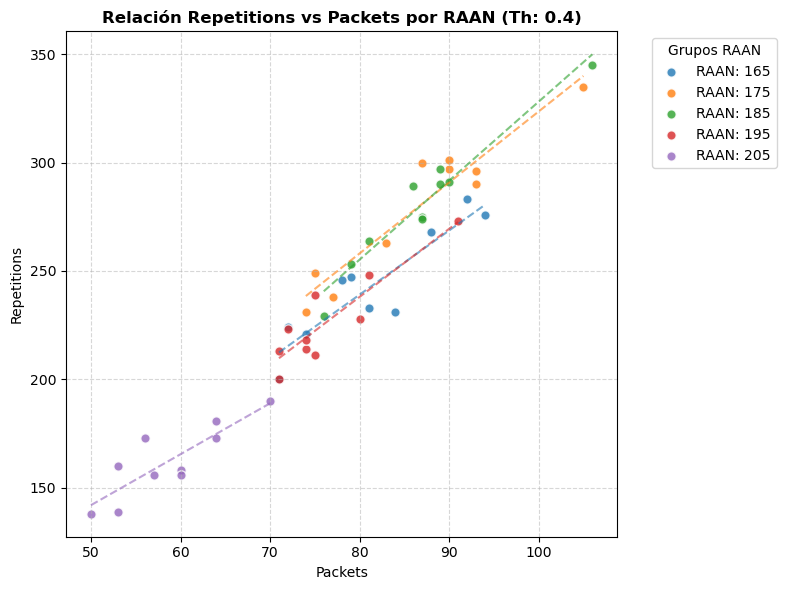

,RAAN,N_Exp,Pkt_Mean,Pkt_Std,Pkt_CV,Rep_Mean,Rep_Std,Rep_CV,Correlation
0,165,10,81.3,7.681797,0.094487,242.9,25.053742,0.103144,0.907368
1,175,10,86.7,9.176601,0.105843,280.0,31.505555,0.112520,0.953603
2,185,10,87.0,7.745967,0.089034,280.7,29.082813,0.103608,0.970372
3,195,10,76.4,5.834381,0.076366,226.7,20.366885,0.089841,0.899787
4,205,10,58.7,5.814637,0.099057,162.4,16.069848,0.098952,0.849954


In [8]:
analyze_threshold_by_raan(transformer_dict_total_data_by_threshold, threshold=0.4)

# Read Metrics for BiLSTM ML model

In [9]:
# Load the CSV files 

folder = "results_florasat_ml_lstm"

total_raans = [165, 175, 185, 195, 205]
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

bilstm_vector_dfs = {}
bilstm_scalar_dfs = {}


for th in thresholds:
    bilstm_vector_dfs[th] = []
    bilstm_scalar_dfs[th] = []
    for raan in total_raans:
        raan_folder = 'raan_' + str(raan)
        bilstm_vector_dfs[th] = bilstm_vector_dfs[th] + [pd.read_csv(os.path.join(folder, raan_folder, f"wML_BiLSTM_raan_{raan}_threshold_{th}_{seed}_vector.csv")) for seed in range(number_of_runs)]
        bilstm_scalar_dfs[th] = bilstm_scalar_dfs[th] + [pd.read_csv(os.path.join(folder, raan_folder, f"wML_BiLSTM_raan_{raan}_threshold_{th}_{seed}_scalar.csv")) for seed in range(number_of_runs)]


In [10]:
bilstm_run_stats_msg_trx_at_dev = {}

for th, config_dfs in bilstm_scalar_dfs.items():
    #mean_values = []
    max_values = []
    min_values = []
    count_values = []
    #all_values = []
    for dataR in config_dfs:
        transmitted_msg_df = dataR[dataR['name'].str.contains('transmittedMessages', na=False)]

        values = []
        for val in transmitted_msg_df['value']:
            values.extend(float(v) for v in str(val).strip('"').split())

        #mean_values.append(np.mean(values) if values else 0)
        max_values.append(np.max(values) if values else 0)
        min_values.append(np.min(values) if values else 0)
        count_values.append(sum(values))
        #all_values.extend(values)        

    bilstm_run_stats_msg_trx_at_dev[th] = {
        #'meanTrxAtDev': np.mean(all_values),
        'avgMaxMsgTrxAtDev': np.mean(max_values),
        'avgMinMsgTrxAtDev': np.mean(min_values),
        'avgCountMsgTrxAtDev': np.mean(count_values)
    }

In [11]:
# Number of repetitions required for successful reception at satellite
bilstm_dict_total_data_by_threshold = {}
bilstm_run_stats_rep_num_at_sat = {}
for th, config_dfs in bilstm_vector_dfs.items():
    bilstm_dict_total_data_by_threshold[th] = {}
        
    #print(f"Processing threshold: {th}")    
    max_values = []
    min_values = []

    # Count of repetitions required for successful reception at satellite counted by the ML model and by the KiWan MAC protocol.
    count_reps_model = [] 
    count_reps_mac   = []

    # Total unique packets received at satellite counted by the ML model and by the KiWan MAC protocol.
    total_pkt_values_model  = []
    total_pkt_values_mac    = []


    for dataR in config_dfs:
        vector_model_df = dataR[dataR['name'].str.contains('Successful Repetition Number counted for the Model', na=False)]
        myraan = extract_myraan(dataR[dataR['attrvalue'].str.contains('myraan', na=False)].iloc[0]['attrvalue'])

        if myraan not in bilstm_dict_total_data_by_threshold[th]:
            bilstm_dict_total_data_by_threshold[th][myraan] = {}
            bilstm_dict_total_data_by_threshold[th][myraan]['Repetitions'] = []
            bilstm_dict_total_data_by_threshold[th][myraan]['Packets'] = []
        
        all_values_model = []
        for vec in vector_model_df['vecvalue']:
            all_values_model.extend(int(val) for val in str(vec).strip('"').split())

        max_values.append(np.max(all_values_model) if all_values_model else 0)
        min_values.append(np.min(all_values_model) if all_values_model else 0)
        count_reps_model.append(sum(all_values_model)) # sum of all repetitions required to recevive in the satellite.
        total_pkt_values_model.append(len(all_values_model)) # total number of packets.

        bilstm_dict_total_data_by_threshold[th][myraan]['Repetitions'].append(sum(all_values_model))
        bilstm_dict_total_data_by_threshold[th][myraan]['Packets'].append(len(all_values_model))

        vector_mac_df = dataR[dataR['name'].str.contains('Successful Repetition Number counted for MAC protocol', na=False)]
        all_values_mac = []
        for vec in vector_mac_df['vecvalue']:
            all_values_mac.extend(int(val) for val in str(vec).strip('"').split())
        
        count_reps_mac.append(sum(all_values_mac)) # sum of all repetitions required to recevive in the satellite for the KiWan
        total_pkt_values_mac.append(len(all_values_mac)) # total number of packets for the KiWan


    #print('count_values: ' , sum(count_values), count_values)
    bilstm_run_stats_rep_num_at_sat[th] = {
        'avgMaxRepAtSat': np.mean(max_values),
        'avgMinRepAtSat': np.mean(min_values),
        'avgCountRepAtSatMac': np.mean(count_reps_mac),
        'avgTotalPktAtSatMac': np.mean(total_pkt_values_mac),
        'avgCountRepAtSatModel': np.mean(count_reps_model),
        'avgTotalPktAtSatModel': np.mean(total_pkt_values_model)
    }


=== ANÁLISIS POR RAAN (THRESHOLD: 0.7) ===
RAAN N_Exp Pkt_Mean Pkt_Std Pkt_CV Rep_Mean Rep_Std Rep_CV Correlation
 165    10    85.90    8.40  9.77%   285.70   28.80 10.08%      0.9387
 175    10    84.10    7.88  9.37%   268.80   27.31 10.16%      0.9410
 185    10    87.40    5.95  6.81%   277.20   20.25  7.31%      0.8785
 195    10    80.30    5.68  7.07%   241.70   21.38  8.84%      0.8579
 205    10    67.50    6.65  9.85%   189.30   20.35 10.75%      0.7250


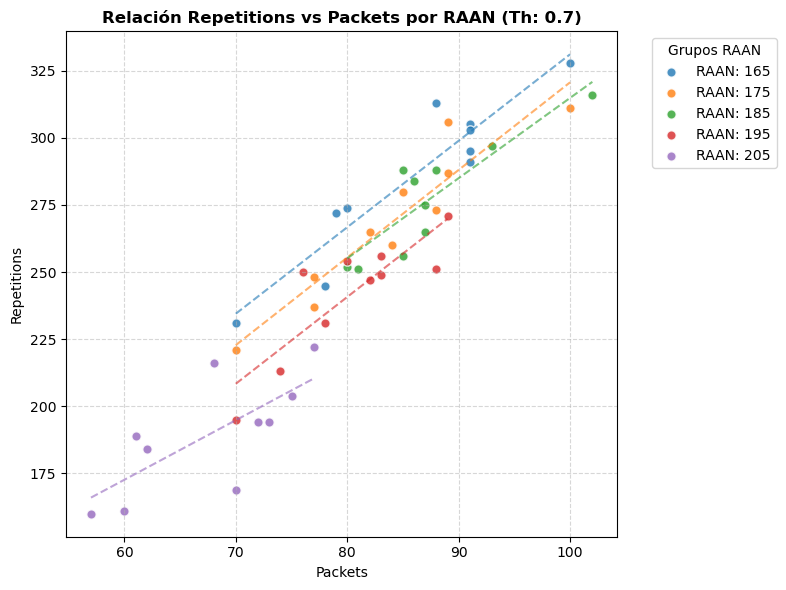

,RAAN,N_Exp,Pkt_Mean,Pkt_Std,Pkt_CV,Rep_Mean,Rep_Std,Rep_CV,Correlation
0,165,10,85.9,8.395832,0.097740,285.7,28.799479,0.100803,0.938685
1,175,10,84.1,7.879721,0.093695,268.8,27.312268,0.101608,0.941021
2,185,10,87.4,5.953150,0.068114,277.2,20.252407,0.073061,0.878526
3,195,10,80.3,5.675385,0.070677,241.7,21.377792,0.088448,0.857928
4,205,10,67.5,6.652067,0.098549,189.3,20.352150,0.107513,0.724976


In [12]:
analyze_threshold_by_raan(bilstm_dict_total_data_by_threshold, threshold=0.7)

# Read Metrics for Analytical

In [13]:
# Load the CSV files 

folder = "results_florasat_analytical"

#thresholds = [0.0005 ,0.0010 ,0.0015 ,0.0020 ,0.0025 ,0.00293 ,0.0035 ,0.0040 ,0.0050 ,0.0075]
#thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
#thresholds = [0.0008, 0.0010, 0.0012, 0.0014, 0.0016, 0.001787, 0.0020, 0.0022, 0.0025,0.0030]
total_raans = [165, 175, 185, 195, 205]
thresholds = [0.0008, 0.0010, 0.0012, 0.0014, 0.0016, 0.001787, 0.0020, 0.0022, 0.0025,0.0030, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
thresholds = [0.00001,0.00010,0.00025,0.00050,0.00075,0.00100,0.00125,0.00150,0.00165,0.001787,0.00190,0.00210,0.00250,0.00350,0.00500,0.00750,0.01000,0.02000,0.05000,0.10000, 0.20000, 0.30000, 0.40000, 0.50000, 0.60000, 0.70000, 0.80000, 0.90000]

#vector_dfs = {}
analytical_scalar_dfs = {}

for th in thresholds:    
    #analytical_scalar_dfs[th] = [pd.read_csv(os.path.join(folder, f"wAnalytical_threshold_{th}_{seed}_scalar.csv")) for seed in range(number_of_runs)]

    analytical_scalar_dfs[th] = []
    for raan in total_raans:
        raan_folder = 'raan_' + str(raan)
        analytical_scalar_dfs[th] = analytical_scalar_dfs[th] + [pd.read_csv(os.path.join(folder, raan_folder, f"wAnalytical_raan_{raan}_threshold_{th}_{seed}_scalar.csv")) for seed in range(number_of_runs)]



In [14]:
analytical_vector_dfs = {}

for th in thresholds:
    dfs = []

    for raan in total_raans:
        raan_folder = 'raan_' + str(raan)
        for seed in range(number_of_runs):
            filename = os.path.join(folder,raan_folder, f"wAnalytical_raan_{raan}_threshold_{th}_{seed}_vector.csv")            
            # wAnalytical_raan_165_threshold_1e-05_6_scalar.csv
            #dfs.append(pd.read_csv(filename))
            ''' 
            try:
                dfs.append(pd.read_csv(filename))
            except Exception as e:
                print('no file', th, seed)
            '''
            ''' 
            try: 
                dfs.append(pd.read_csv(filename))
            except FileNotFoundError:
                print('filename: ', filename)
                print('no file', th, seed)
            ''' 
            if os.path.isfile(filename):
                dfs.append(pd.read_csv(filename))
            else:
                print(f"File {filename} does not exist.")
            
            #wAnalytical_raan_165_threshold_0.0001_0_vector.csv
            #results_florasat_analytical/raan_165
    
    analytical_vector_dfs[th] = dfs

File results_florasat_analytical/raan_165/wAnalytical_raan_165_threshold_0.4_0_vector.csv does not exist.
File results_florasat_analytical/raan_165/wAnalytical_raan_165_threshold_0.4_1_vector.csv does not exist.
File results_florasat_analytical/raan_165/wAnalytical_raan_165_threshold_0.4_2_vector.csv does not exist.
File results_florasat_analytical/raan_165/wAnalytical_raan_165_threshold_0.4_3_vector.csv does not exist.
File results_florasat_analytical/raan_165/wAnalytical_raan_165_threshold_0.4_4_vector.csv does not exist.
File results_florasat_analytical/raan_165/wAnalytical_raan_165_threshold_0.4_5_vector.csv does not exist.
File results_florasat_analytical/raan_165/wAnalytical_raan_165_threshold_0.4_6_vector.csv does not exist.
File results_florasat_analytical/raan_165/wAnalytical_raan_165_threshold_0.4_7_vector.csv does not exist.
File results_florasat_analytical/raan_165/wAnalytical_raan_165_threshold_0.4_8_vector.csv does not exist.
File results_florasat_analytical/raan_165/wAna

In [15]:
analytical_run_stats_msg_trx_at_dev = {}

for th, config_df in analytical_scalar_dfs.items():
    #mean_values = []
    max_values = []
    min_values = []
    count_values = []
    #all_values = []
    for dataR in config_df:
        transmitted_msg_df = dataR[dataR['name'].str.contains('transmittedMessages', na=False)]

        values = []
        for val in transmitted_msg_df['value']:
            values.extend(float(v) for v in str(val).strip('"').split())

        #mean_values.append(np.mean(values) if values else 0)
        max_values.append(np.max(values) if values else 0)
        min_values.append(np.min(values) if values else 0)
        count_values.append(sum(values))
        #all_values.extend(values)

    analytical_run_stats_msg_trx_at_dev[th] = {
        #'meanTrxAtDev': np.mean(all_values),
        'avgMaxMsgTrxAtDev': np.mean(max_values),
        'avgMinMsgTrxAtDev': np.mean(min_values),
        'avgCountMsgTrxAtDev': np.mean(count_values)
    }

In [16]:
# Number of repetitions required for successful reception at satellite
analytical_run_stats_rep_num_at_sat = {}
for th, config_df in analytical_vector_dfs.items():
    if not config_df:
        analytical_run_stats_rep_num_at_sat[th] = {
            'avgMaxRepAtSat': 0,
            'avgMinRepAtSat': 0,
            'avgCountRepAtSatMac': 0,
            'avgTotalPktAtSatMac': 0,
            'avgCountRepAtSatModel': 0,
            'avgTotalPktAtSatModel': 0
        }
        continue

    #print(f"Processing threshold: {th}")    
    max_values = []
    min_values = []

    # Count of repetitions required for successful reception at satellite counted by the ML model and by the KiWan MAC protocol.
    count_reps_model = [] 
    count_reps_mac   = []

    # Total unique packets received at satellite counted by the ML model and by the KiWan MAC protocol.
    total_pkt_values_model  = []
    total_pkt_values_mac    = []
    
    for dataR in config_df:
        vector_model_df = dataR[dataR['name'].str.contains('Successful Repetition Number counted for the Model', na=False)]
        all_values_model = []

        for vec in vector_model_df['vecvalue']:
            all_values_model.extend(int(val) for val in str(vec).strip('"').split())

        max_values.append(np.max(all_values_model) if all_values_model else 0)
        min_values.append(np.min(all_values_model) if all_values_model else 0)
        count_reps_model.append(sum(all_values_model)) # sum of all repetitions required to recevive in the satellite.
        total_pkt_values_model.append(len(all_values_model)) # total number of packets.

        vector_mac_df = dataR[dataR['name'].str.contains('Successful Repetition Number counted for MAC protocol', na=False)]
        all_values_mac = []
        for vec in vector_mac_df['vecvalue']:
            all_values_mac.extend(int(val) for val in str(vec).strip('"').split())
        
        count_reps_mac.append(sum(all_values_mac)) # sum of all repetitions required to recevive in the satellite for the KiWan
        total_pkt_values_mac.append(len(all_values_mac)) # total number of packets for the KiWan

    #print('count_reps_model: ', len(count_reps_model), sum(count_reps_model))
    #print('total_pkt_values_model: ', len(total_pkt_values_model), sum(total_pkt_values_model))
    analytical_run_stats_rep_num_at_sat[th] = {
        'avgMaxRepAtSat': np.mean(max_values),
        'avgMinRepAtSat': np.mean(min_values),
        'avgCountRepAtSatMac': np.mean(count_reps_mac),
        'avgTotalPktAtSatMac': np.mean(total_pkt_values_mac),
        'avgCountRepAtSatModel': np.mean(count_reps_model),
        'avgTotalPktAtSatModel': np.mean(total_pkt_values_model)
    }


In [17]:
analytical_run_stats_rep_num_at_sat.keys()

analytical_run_stats_rep_num_at_sat[0.3]

{'avgMaxRepAtSat': np.float64(5.0),
 'avgMinRepAtSat': np.float64(1.12),
 'avgCountRepAtSatMac': np.float64(310.78),
 'avgTotalPktAtSatMac': np.float64(88.68),
 'avgCountRepAtSatModel': np.float64(310.1),
 'avgTotalPktAtSatModel': np.float64(88.68)}

# Read Metrics for NoML

In [18]:
# Load the CSV files 

folder = "results_florasat_no_ml"
total_raans = [165, 175, 185, 195, 205]


vector_files = []
scalar_files = []

for raan in total_raans:
    # wNoML_raan_175_run_10_vector
    raan_folder = 'raan_'+str(raan)    
    vector_files = vector_files +[os.path.join(folder, raan_folder, f"wNoML_raan_{raan}_run_{i}_vector.csv") for i in range(0, number_of_runs)]
    scalar_files = scalar_files +[os.path.join(folder, raan_folder, f"wNoML_raan_{raan}_run_{i}_scalar.csv") for i in range(0, number_of_runs)]


no_ml_vector_dfs = [pd.read_csv(f) for f in vector_files]
no_ml_scalar_dfs = [pd.read_csv(f) for f in scalar_files]

In [19]:
no_ml_run_stats_msg_trx_at_dev = []

for run_idx, dataR in enumerate(no_ml_scalar_dfs):
    transmitted_msg_df = dataR[dataR['name'].str.contains('transmittedMessages', na=False)].copy()
    
    values = []    
    for val in transmitted_msg_df['value']:        
        values.extend([float(v) for v in str(val).strip('"').split()])
    
    no_ml_run_stats_msg_trx_at_dev.append({
        'meanMsgTrxAtDev': np.mean(values) if values else 0,
        'maxMsgTrxAtDev': np.max(values) if values else 0,
        'minMsgTrxAtDev': np.min(values) if values else 0,
        'countMsgTrxAtDev': int(sum(values))
    })

In [20]:
# Number of repetitions required for successful reception at satellite
no_ml_run_stats_rep_num_at_sat = []

for run_idx, dataR in enumerate(no_ml_vector_dfs):
    #print('run_idx: ', run_idx)
    nodeGenDelayRep_df = dataR[dataR['name'].str.contains('Successful Repetition Number counted for MAC protocol', na=False)].copy()
    all_reps = []
    for vec in nodeGenDelayRep_df['vecvalue']:
        all_reps.extend([int(val) for val in str(vec).strip('"').split()])
    #print('all_reps: ', sum(all_reps), len(all_reps))
    no_ml_run_stats_rep_num_at_sat.append({
        #'meanRepAtSat': np.mean(all_reps) if all_reps else 0,
        'avgMaxRepAtSat': np.max(all_reps) if all_reps else 0,
        'avgMinRepAtSat': np.min(all_reps) if all_reps else 0,
        'avgCountRepAtSatMac': sum(all_reps), 
        'avgTotalPktAtSatMac': len(all_reps),
        'avgCountRepAtSatModel': sum(all_reps), 
        'avgTotalPktAtSatModel': len(all_reps),
    })

# Preprocess to create plot

In [21]:

rows = []

# Suponiendo que los tres diccionarios tienen los mismos thresholds
for th in sorted(transformer_run_stats_rep_num_at_sat.keys()):

    trf_dev = transformer_run_stats_msg_trx_at_dev.get(th, {})
    bilstm_dev = bilstm_run_stats_msg_trx_at_dev.get(th, {})
    analytical_dev = analytical_run_stats_msg_trx_at_dev.get(th, {})

    trf_sat = transformer_run_stats_rep_num_at_sat.get(th, {})
    bilstm_sat = bilstm_run_stats_rep_num_at_sat.get(th, {})
    analytical_sat = analytical_run_stats_rep_num_at_sat.get(th, {})

    if th not in analytical_run_stats_rep_num_at_sat.keys():        
        analytical_avgMaxRepAtSat = 0
        analytical_avgMinRepAtSat = 0
        analytical_avgCountRepAtSatMac   = 0
        analytical_avgCountRepAtSatModel = 0
        analytical_avgTotalPktAtSatMac   = 0
        analytical_avgTotalPktAtSatModel = 0
        analytical_avgMaxMsgTrxAtDev = 0
        analytical_avgMinMsgTrxAtDev = 0
        analytical_avgCountMsgTrxAtDev = 0
    else:
        analytical_avgMaxRepAtSat = analytical_sat.get("avgMaxRepAtSat", 0)
        analytical_avgMinRepAtSat = analytical_sat.get("avgMinRepAtSat", 0)
        analytical_avgCountRepAtSatMac = analytical_sat.get("avgCountRepAtSatMac", 0)
        analytical_avgCountRepAtSatModel = analytical_sat.get("avgCountRepAtSatModel", 0)
        analytical_avgTotalPktAtSatMac = analytical_sat.get("avgTotalPktAtSatMac", 0)
        analytical_avgTotalPktAtSatModel = analytical_sat.get("avgTotalPktAtSatModel", 0)

        analytical_avgMaxMsgTrxAtDev = analytical_dev.get("avgMaxMsgTrxAtDev", 0)
        analytical_avgMinMsgTrxAtDev = analytical_dev.get("avgMinMsgTrxAtDev", 0)
        analytical_avgCountMsgTrxAtDev = analytical_dev.get("avgCountMsgTrxAtDev", 0)

    rows.append({
        "threshold": th,

        #"transformer_avgMaxRepAtSat": trf_sat.get("avgMaxRepAtSat", 0),
        #"transformer_avgMinRepAtSat": trf_sat.get("avgMinRepAtSat", 0),
        "transformer_avgCountRepAtSatMac": trf_sat.get("avgCountRepAtSatMac", 0),
        "transformer_avgCountRepAtSatModel": trf_sat.get("avgCountRepAtSatModel", 0),
        "transformer_avgTotalPktAtSatMac": trf_sat.get("avgTotalPktAtSatMac", 0),
        "transformer_avgTotalPktAtSatModel": trf_sat.get("avgTotalPktAtSatModel", 0),
        #"transformer_avgMaxMsgTrxAtDev": trf_dev.get("avgMaxMsgTrxAtDev", 0),
        #"transformer_avgMinMsgTrxAtDev": trf_dev.get("avgMinMsgTrxAtDev", 0),
        #"transformer_avgCountMsgTrxAtDev": trf_dev.get("avgCountMsgTrxAtDev", 0),


        #"bilstm_avgMaxRepAtSat": bilstm_sat.get("avgMaxRepAtSat", 0),
        #"bilstm_avgMinRepAtSat": bilstm_sat.get("avgMinRepAtSat", 0),
        "bilstm_avgCountRepAtSatMac": bilstm_sat.get("avgCountRepAtSatMac", 0),
        "bilstm_avgCountRepAtSatModel": bilstm_sat.get("avgCountRepAtSatModel", 0),
        "bilstm_avgTotalPktAtSatMac": bilstm_sat.get("avgTotalPktAtSatMac", 0),        
        "bilstm_avgTotalPktAtSatModel": bilstm_sat.get("avgTotalPktAtSatModel", 0),
        #"bilstm_avgMaxMsgTrxAtDev": bilstm_dev.get("avgMaxMsgTrxAtDev", 0),
        #"bilstm_avgMinMsgTrxAtDev": bilstm_dev.get("avgMinMsgTrxAtDev", 0),
        #"bilstm_avgCountMsgTrxAtDev": bilstm_dev.get("avgCountMsgTrxAtDev", 0),

        #"analytical_avgMaxRepAtSat": analytical_avgMaxRepAtSat,
        #"analytical_avgMinRepAtSat": analytical_avgMinRepAtSat,
        "analytical_avgCountRepAtSatMac": analytical_avgCountRepAtSatMac,
        "analytical_avgCountRepAtSatModel": analytical_avgCountRepAtSatModel,        
        "analytical_avgTotalPktAtSatMac": analytical_avgTotalPktAtSatMac,
        "analytical_avgTotalPktAtSatModel": analytical_avgTotalPktAtSatModel,
        #"analytical_avgMaxMsgTrxAtDev": analytical_avgMaxMsgTrxAtDev,
        #"analytical_avgMinMsgTrxAtDev": analytical_avgMinMsgTrxAtDev,
        #"analytical_avgCountMsgTrxAtDev": analytical_avgCountMsgTrxAtDev,

    })


for th in sorted(analytical_run_stats_rep_num_at_sat.keys()):
    if th not in [row["threshold"] for row in rows]:
    #if th not in [row["threshold"] for row in rows]:
        analytical_dev = analytical_run_stats_msg_trx_at_dev.get(th, {})
        analytical_sat = analytical_run_stats_rep_num_at_sat.get(th, {})

        rows.append({
            "threshold": th,

            #"transformer_avgMaxRepAtSat": 0,
            #"transformer_avgMinRepAtSat": 0,
            "transformer_avgCountRepAtSatModel": 0,
            "transformer_avgTotalPktAtSatModel": 0,
            "transformer_avgCountRepAtSatMac": 0,
            "transformer_avgTotalPktAtSatMac": 0,
            #"transformer_avgMaxMsgTrxAtDev": 0,
            #"transformer_avgMinMsgTrxAtDev": 0,
            #"transformer_avgCountMsgTrxAtDev": 0,

            #"bilstm_avgMaxRepAtSat": 0,
            #"bilstm_avgMinRepAtSat": 0,
            "bilstm_avgCountRepAtSatModel": 0,
            "bilstm_avgTotalPktAtSatModel": 0,
            "bilstm_avgCountRepAtSatMac": 0,
            "bilstm_avgTotalPktAtSatMac": 0,            
            #"bilstm_avgMaxMsgTrxAtDev": 0,
            #"bilstm_avgMinMsgTrxAtDev": 0,
            #"bilstm_avgCountMsgTrxAtDev": 0,

            #"analytical_avgMaxRepAtSat": analytical_sat.get("avgMaxRepAtSat", 0),
            #"analytical_avgMinRepAtSat": analytical_sat.get("avgMinRepAtSat", 0),
            "analytical_avgCountRepAtSatMac": analytical_sat.get("avgCountRepAtSatMac", 0),
            "analytical_avgCountRepAtSatModel": analytical_sat.get("avgCountRepAtSatModel", 0),
            "analytical_avgTotalPktAtSatMac": analytical_sat.get("avgTotalPktAtSatMac", 0),
            "analytical_avgTotalPktAtSatModel": analytical_sat.get("avgTotalPktAtSatModel", 0),
            #"analytical_avgMaxMsgTrxAtDev": analytical_dev.get("avgMaxMsgTrxAtDev", 0),
            #"analytical_avgMinMsgTrxAtDev": analytical_dev.get("avgMinMsgTrxAtDev", 0),
            #"analytical_avgCountMsgTrxAtDev": analytical_dev.get("avgCountMsgTrxAtDev", 0),
        })

df = pd.DataFrame(rows)
df.to_csv("comparison_rep_num_at_sat.csv", index=False)

In [22]:
df[['threshold','transformer_avgCountRepAtSatModel', 'transformer_avgTotalPktAtSatModel', 'bilstm_avgCountRepAtSatModel', 'bilstm_avgTotalPktAtSatModel', 'analytical_avgCountRepAtSatModel', 'analytical_avgTotalPktAtSatModel']].head(10)

,threshold,transformer_avgCountRepAtSatModel,transformer_avgTotalPktAtSatModel,bilstm_avgCountRepAtSatModel,bilstm_avgTotalPktAtSatModel,analytical_avgCountRepAtSatModel,analytical_avgTotalPktAtSatModel
0,0.10,312.00,91.06,282.90,79.98,307.52,87.76
1,0.20,301.12,91.00,283.78,80.34,308.48,88.12
2,0.30,272.14,85.52,289.86,82.24,310.10,88.68
3,0.40,238.54,78.02,299.20,84.98,0.00,0.00
4,0.50,205.54,70.16,299.76,86.92,0.00,0.00
5,0.60,171.06,60.98,283.70,85.66,0.00,0.00
6,0.70,134.40,50.86,252.54,81.04,0.00,0.00
7,0.80,96.52,39.72,200.44,71.60,0.00,0.00
8,0.90,53.04,23.92,110.98,46.62,0.00,0.00
9,0.95,33.90,14.38,51.72,24.78,0.00,0.00


# Generate graphics

<>:131: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:131: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:132: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:132: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:131: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:131: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:132: SyntaxWarning: "\m" is an invalid escape sequence. Such sequen

Processing model: Transformer-Encoder
Processing model: BiLSTM
Processing model: Analytical


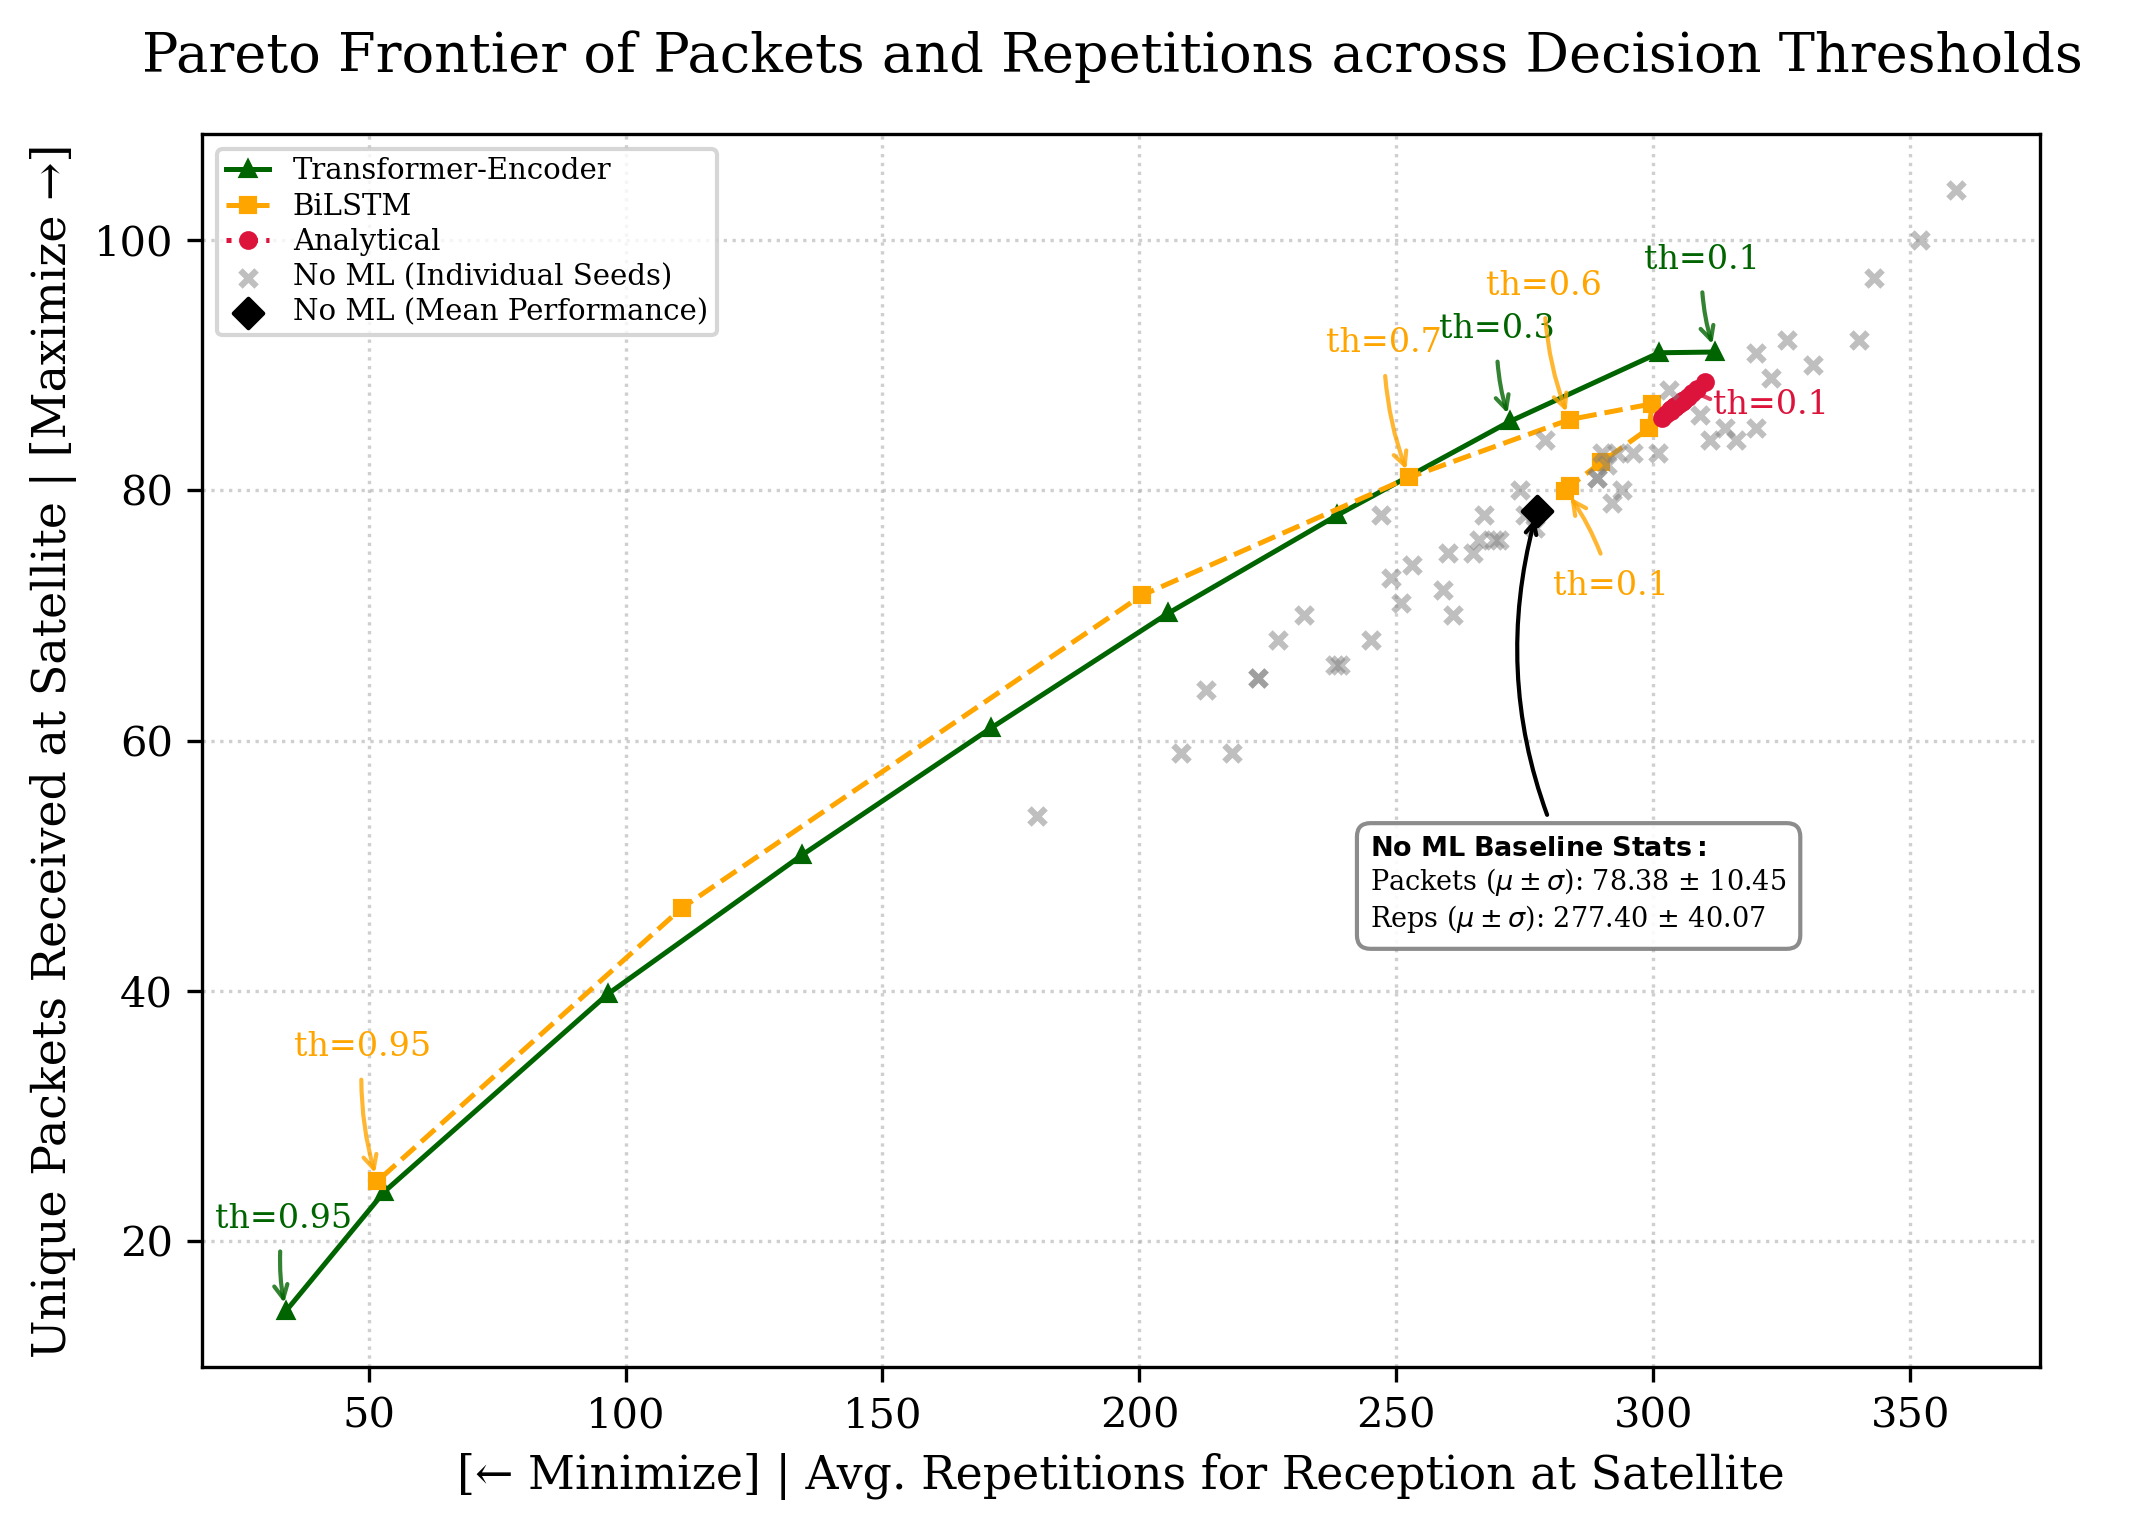

In [100]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
#from sympy import Ellipse
from matplotlib.patches import Ellipse

df = pd.read_csv("comparison_rep_num_at_sat.csv")

th_bilstm_transformer = [0.100000,0.200000,0.300000,0.400000,0.500000,0.600000,0.700000,0.800000,0.900000,0.950000]
#th_analytical = [0.0008, 0.0010, 0.0012, 0.0014, 0.0016, 0.001787, 0.0020, 0.0022, 0.0025,0.0030, 0.100000,0.200000,0.300000,0.400000,0.500000,0.600000,0.700000,0.800000,0.900000,0.950000]
th_analytical = [0.00001,0.00010,0.00025,0.00050,0.00075,0.00100,0.00125,0.00150,0.00165,0.001787,0.00190,0.00210,0.00250,0.00350,0.00500,0.00750,0.01000,0.02000,0.05000,0.10000,0.20000,0.30000,0.40000,0.50000,0.60000,0.70000,0.80000,0.90000]


models = {
    "Transformer-Encoder": {
        "x": "transformer_avgCountRepAtSatModel",
        "y": "transformer_avgTotalPktAtSatModel",
        "color": "darkgreen",
        "marker": "^",
        "ls": "-"
    },
    "BiLSTM": {
        "x": "bilstm_avgCountRepAtSatModel",
        "y": "bilstm_avgTotalPktAtSatModel",
        "color": "orange",
        "marker": "s",
        "ls": "--"
    },
    "Analytical": {
        "x": "analytical_avgCountRepAtSatModel",
        "y": "analytical_avgTotalPktAtSatModel",
        "color": "crimson",
        "marker": "o",
        "ls": ":"
    }
}

#plt.figure(figsize=(10, 7))
#plt.figure(figsize=(7, 5.2))
fig, ax = plt.subplots(figsize=(7, 5.2), dpi=300)
#fig, ax = plt.subplots(figsize=(3.5, 2.6))

for model, config in models.items():
    #df_sorted = df.sort_values(by="threshold")
    print(f"Processing model: {model}")

    if model == "Transformer-Encoder":
        th_to_plot = [0.1, 0.3, 0.95]
    elif model == "BiLSTM":
        th_to_plot = [0.1, 0.6, 0.7, 0.95]

    if model == "Transformer-Encoder" or model == "BiLSTM":
        thresholds = np.array(th_bilstm_transformer)
        aux_df = df[df["threshold"].isin(th_bilstm_transformer)]
        df_sorted = aux_df.sort_values(by="threshold")
        
    elif model == "Analytical":
        thresholds = np.array(th_analytical)
        aux_df = df[df["threshold"].isin(th_analytical)]
        df_sorted = aux_df.sort_values(by="threshold")
        th_to_plot = [0.0008, 0.0030, 0.1] #0.0016,


    x_vals = df_sorted[config["x"]].to_numpy(dtype=float)
    y_vals = df_sorted[config["y"]].to_numpy(dtype=float)


    #if model != "No ML":
    mask = x_vals != 0
    x_vals = x_vals[mask]
    y_vals = y_vals[mask]
    thresholds = thresholds[mask]
    
    plt.plot(x_vals, y_vals, label=model, color=config["color"], linestyle=config["ls"], marker=config["marker"], linewidth=1.2, markersize=3.5)
    
    for idx in range(len(thresholds)):
        th = thresholds[idx]
        if th not in th_to_plot:
            continue

        if model == "Transformer-Encoder":
            offset_x, offset_y = -17, 20
        elif model == "BiLSTM":
            offset_x, offset_y = -20, 30 #-18

            if th == 0.1:
                offset_x, offset_y = -3, -25 #-18
        else:
            offset_x, offset_y = 5, -5
        
        #offset_x, offset_y = 0, 0
        plt.annotate(
            f"th={thresholds[idx]}",
            (x_vals[idx], y_vals[idx]),
            xytext=(offset_x, offset_y),
            textcoords="offset points",
            fontsize=8,
            color=config["color"],
            #weight='bold' if "Transformer" in nombre_modelo else 'normal'
            #weight = 'normal'
            arrowprops=dict(
                arrowstyle="->",
                color=config["color"],
                lw=1,
                alpha=0.8,
                connectionstyle="arc3,rad=0.1"  # Curvatura elegante en la flecha
            )
        )


# --- 2. Graficar No ML como Nube y Región Estadística ---
df_no_ml = pd.DataFrame(no_ml_run_stats_rep_num_at_sat)
x_no_ml = df_no_ml["avgCountRepAtSatModel"].to_numpy()
y_no_ml = df_no_ml["avgTotalPktAtSatModel"].to_numpy()

# Nube de puntos gris (seeds individuales)
plt.scatter(x_no_ml, y_no_ml, color="gray", alpha=0.5, marker="x", s=15, label="No ML (Individual Seeds)", zorder=2)

# Diamante negro central (promedio estadístico)
#mean_x = np.mean(x_no_ml)
#mean_y = np.mean(y_no_ml)

mean_x, std_x = np.mean(x_no_ml), np.std(x_no_ml)
mean_y, std_y = np.mean(y_no_ml), np.std(y_no_ml)

plt.scatter(mean_x, mean_y, color="black", marker="D", s=25, label="No ML (Mean Performance)", zorder=4)

stats_text = (
    r"$\mathbf{No\ ML\ Baseline\ Stats:}$"
    "\n"
    f"Packets ($\mu \pm \sigma$): {mean_y:.2f} $\pm$ {std_y:.2f}\n"
    f"Reps ($\mu \pm \sigma$): {mean_x:.2f} $\pm$ {std_x:.2f}"
)

plt.annotate(
    stats_text,
    xy=(mean_x, mean_y),
    xytext=(
        -40,
        -100,
    ),  # Posición relativa de la caja de texto (ajustable según conveniencia)
    textcoords="offset points",
    fontsize=6.5,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9,
    ),
    arrowprops=dict(
        arrowstyle="->", connectionstyle="arc3,rad=-0.2", color="black", lw=1
    ),
    zorder=5,
)

plt.title("Pareto Frontier of Packets and Repetitions across Decision Thresholds ", fontsize=13, pad=15)
plt.ylabel("Unique Packets Received at Satellite | [Maximize →]", fontsize=11)
plt.xlabel("[← Minimize] | Avg. Repetitions for Reception at Satellite", fontsize=11)

#plt.gca().invert_xaxis()
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left", fontsize=7, ncol=1, edgecolor="#cccccc",handlelength=1.5,borderpad=0.3,labelspacing=0.25,) # lower left
plt.tight_layout()

plt.savefig("pareto_frontier.pdf", dpi=300)
plt.show()
plt.close()

# New Plot

In [25]:
df.columns
df_no_ml.columns
no_ml_pkt = df_no_ml['avgTotalPktAtSatMac'].mean()
no_ml_pkt

np.float64(78.38)

In [26]:
df_transformer = df[df['threshold'].isin(th_bilstm_transformer)][['threshold','transformer_avgCountRepAtSatModel', 'transformer_avgTotalPktAtSatModel']]
no_ml_rep = df_no_ml['avgCountRepAtSatMac'].mean()
no_ml_pkt = df_no_ml['avgTotalPktAtSatMac'].mean()
print('no_ml_rep: ', no_ml_rep)
print('no_ml_pkt: ', no_ml_pkt)
df_transformer['no_ml_rep'] = no_ml_rep
df_transformer['no_ml_pkt'] = no_ml_pkt
df_transformer['diff_reps_vs_noml(%)_Reduce'] = 100 - (df_transformer['transformer_avgCountRepAtSatModel'] * 100) / no_ml_rep
df_transformer['diff_pkts_vs_noml(%)_Maximize'] = ((df_transformer['transformer_avgTotalPktAtSatModel'] * 100) / no_ml_pkt) - 100
df_transformer

no_ml_rep:  277.4
no_ml_pkt:  78.38


,threshold,transformer_avgCountRepAtSatModel,transformer_avgTotalPktAtSatModel,no_ml_rep,no_ml_pkt,diff_reps_vs_noml(%)_Reduce,diff_pkts_vs_noml(%)_Maximize
0,0.10,312.00,91.06,277.4,78.38,-12.472963,16.177596
1,0.20,301.12,91.00,277.4,78.38,-8.550829,16.101046
2,0.30,272.14,85.52,277.4,78.38,1.896179,9.109467
3,0.40,238.54,78.02,277.4,78.38,14.008652,-0.459301
4,0.50,205.54,70.16,277.4,78.38,25.904831,-10.487369
5,0.60,171.06,60.98,277.4,78.38,38.334535,-22.199541
6,0.70,134.40,50.86,277.4,78.38,51.550108,-35.110998
7,0.80,96.52,39.72,277.4,78.38,65.205479,-49.323807
8,0.90,53.04,23.92,277.4,78.38,80.879596,-69.482011
9,0.95,33.90,14.38,277.4,78.38,87.779380,-81.653483


In [27]:
df_bilstm = df[df['threshold'].isin(th_bilstm_transformer)][['threshold','bilstm_avgCountRepAtSatModel', 'bilstm_avgTotalPktAtSatModel']]
no_ml_rep = df_no_ml['avgCountRepAtSatMac'].mean()
no_ml_pkt = df_no_ml['avgTotalPktAtSatMac'].mean()
print('no_ml_rep: ', no_ml_rep)
print('no_ml_pkt: ', no_ml_pkt)
df_bilstm['no_ml_rep'] = no_ml_rep
df_bilstm['no_ml_pkt'] = no_ml_pkt
df_bilstm['diff_reps_vs_noml(%)_Reduce'] = 100 - (df_bilstm['bilstm_avgCountRepAtSatModel'] * 100) / no_ml_rep
df_bilstm['diff_pkts_vs_noml(%)_Maximize'] = ((df_bilstm['bilstm_avgTotalPktAtSatModel'] * 100) / no_ml_pkt) - 100
df_bilstm

no_ml_rep:  277.4
no_ml_pkt:  78.38


,threshold,bilstm_avgCountRepAtSatModel,bilstm_avgTotalPktAtSatModel,no_ml_rep,no_ml_pkt,diff_reps_vs_noml(%)_Reduce,diff_pkts_vs_noml(%)_Maximize
0,0.10,282.90,79.98,277.4,78.38,-1.982696,2.041337
1,0.20,283.78,80.34,277.4,78.38,-2.299928,2.500638
2,0.30,289.86,82.24,277.4,78.38,-4.491709,4.924726
3,0.40,299.20,84.98,277.4,78.38,-7.858688,8.420515
4,0.50,299.76,86.92,277.4,78.38,-8.060562,10.895637
5,0.60,283.70,85.66,277.4,78.38,-2.271089,9.288084
6,0.70,252.54,81.04,277.4,78.38,8.961788,3.393723
7,0.80,200.44,71.60,277.4,78.38,27.743331,-8.650166
8,0.90,110.98,46.62,277.4,78.38,59.992790,-40.520541
9,0.95,51.72,24.78,277.4,78.38,81.355443,-68.384792


In [28]:
th_analytical

[1e-05,
 0.0001,
 0.00025,
 0.0005,
 0.00075,
 0.001,
 0.00125,
 0.0015,
 0.00165,
 0.001787,
 0.0019,
 0.0021,
 0.0025,
 0.0035,
 0.005,
 0.0075,
 0.01,
 0.02,
 0.05,
 0.1,
 0.2,
 0.3,
 0.4,
 0.5,
 0.6,
 0.7,
 0.8,
 0.9]

In [29]:
df_analytical = df[df['threshold'].isin(th_analytical)][['threshold','analytical_avgCountRepAtSatModel', 'analytical_avgTotalPktAtSatModel']]
no_ml_rep = df_no_ml['avgCountRepAtSatMac'].mean()
no_ml_pkt = df_no_ml['avgTotalPktAtSatMac'].mean()
print('no_ml_rep: ', no_ml_rep)
print('no_ml_pkt: ', no_ml_pkt)
df_analytical['no_ml_rep'] = no_ml_rep
df_analytical['no_ml_pkt'] = no_ml_pkt
df_analytical['diff_reps_vs_noml(%)_Reduce'] = 100 - (df_analytical['analytical_avgCountRepAtSatModel'] * 100) / no_ml_rep
df_analytical['diff_pkts_vs_noml(%)_Maximize'] = ((df_analytical['analytical_avgTotalPktAtSatModel'] * 100) / no_ml_pkt) - 100
df_analytical


no_ml_rep:  277.4
no_ml_pkt:  78.38


,threshold,analytical_avgCountRepAtSatModel,analytical_avgTotalPktAtSatModel,no_ml_rep,no_ml_pkt,diff_reps_vs_noml(%)_Reduce,diff_pkts_vs_noml(%)_Maximize
0,0.100000,307.52,87.76,277.4,78.38,-10.857967,11.967339
1,0.200000,308.48,88.12,277.4,78.38,-11.204037,12.426639
2,0.300000,310.10,88.68,277.4,78.38,-11.788032,13.141107
3,0.400000,0.00,0.00,277.4,78.38,100.000000,-100.000000
4,0.500000,0.00,0.00,277.4,78.38,100.000000,-100.000000
5,0.600000,0.00,0.00,277.4,78.38,100.000000,-100.000000
6,0.700000,0.00,0.00,277.4,78.38,100.000000,-100.000000
7,0.800000,0.00,0.00,277.4,78.38,100.000000,-100.000000
8,0.900000,0.00,0.00,277.4,78.38,100.000000,-100.000000
10,0.000010,301.68,85.76,277.4,78.38,-8.752704,9.415667


In [30]:
df[df["threshold"] == 0.7][['threshold','bilstm_avgCountRepAtSatMac', 'bilstm_avgCountRepAtSatModel', 'bilstm_avgTotalPktAtSatMac', 'bilstm_avgTotalPktAtSatModel']]



,threshold,bilstm_avgCountRepAtSatMac,bilstm_avgCountRepAtSatModel,bilstm_avgTotalPktAtSatMac,bilstm_avgTotalPktAtSatModel
6,0.7,267.58,252.54,81.04,81.04


In [31]:
df['bilstm_diffCountRepAtSat'] = df['bilstm_avgCountRepAtSatMac'] - df['bilstm_avgCountRepAtSatModel']
df['transformer_diffCountRepAtSat'] = df['transformer_avgCountRepAtSatMac'] - df['transformer_avgCountRepAtSatModel']
df['analytical_diffCountRepAtSat'] = df['analytical_avgCountRepAtSatMac'] - df['analytical_avgCountRepAtSatModel']

In [32]:
df[['threshold', 'bilstm_diffCountRepAtSat', 'transformer_diffCountRepAtSat', 'analytical_diffCountRepAtSat']]

,threshold,bilstm_diffCountRepAtSat,transformer_diffCountRepAtSat,analytical_diffCountRepAtSat
0,0.100000,0.00,3.02,0.44
1,0.200000,0.04,6.60,0.52
2,0.300000,0.64,8.84,0.68
3,0.400000,1.64,9.34,0.00
4,0.500000,3.72,9.64,0.00
5,0.600000,7.50,10.72,0.00
6,0.700000,15.04,11.72,0.00
7,0.800000,25.30,11.54,0.00
8,0.900000,20.08,9.10,0.00
9,0.950000,14.90,4.60,0.00
